### **INN** **Hotel**

**Objective** :
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

Importing all the necessary libraries.
The following libraries are used for:
- Data manipulation
- Visualization
- Machine Learning
- Model Evaluation

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Loading Dataset

The dataset is loaded into a pandas dataframe for analysis and preprocessing.

In [13]:
data = pd.read_csv("/INNHotelsGroup.csv")


# Basic Data Exploration

Initial exploration is performed to understand:
- Dataset shape
- Data types
- Missing values
- Statistical summary

In [14]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [15]:
data.shape


(36275, 19)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [17]:
data.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


# Handling Missing Values

Missing values can negatively affect machine learning models.

The dataset is checked for null values and appropriate preprocessing steps are applied if necessary.

In [18]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


# Checking Duplicate Records

Duplicate records are identified and removed to improve data quality and prevent biased model training.

In [19]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
36270,False
36271,False
36272,False
36273,False


In [20]:
data.drop_duplicates()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


# Exploratory Data Analysis (EDA)

EDA is performed to identify:
- Booking patterns
- Customer behavior
- Cancellation trends
- Relationships between variables

Visualizations are used for better understanding of the data.

**What are the busiest months in the hotel?**

<Axes: xlabel='arrival_month', ylabel='count'>

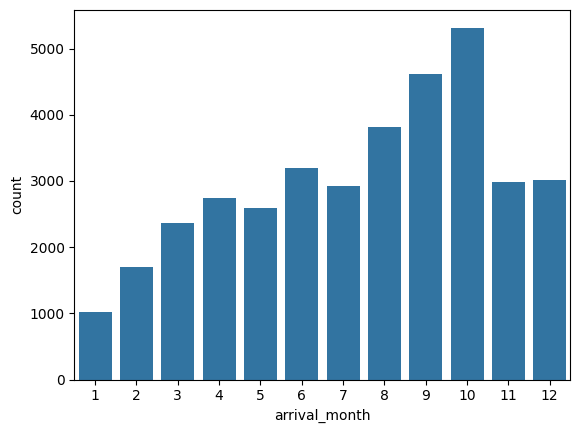

In [21]:
sns.countplot(x="arrival_month",data=data)

Hence according to our observeation **October** is the busiest month.

**Which market segment do most of the guests come from?**


<Axes: xlabel='market_segment_type', ylabel='count'>

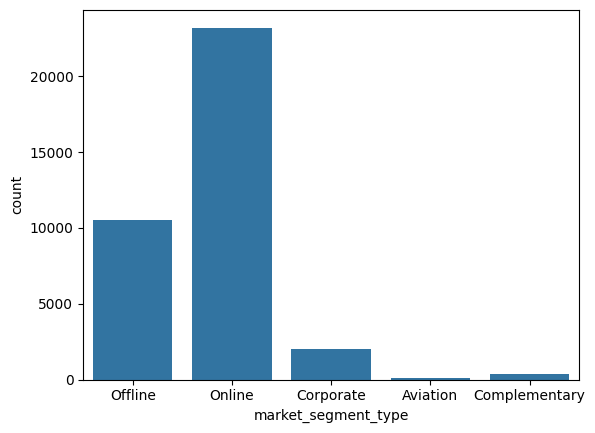

In [22]:
sns.countplot(x="market_segment_type",data=data)


Hence according to our observation guest choose **Online** market segment more.

**Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

<Axes: xlabel='market_segment_type', ylabel='avg_price_per_room'>

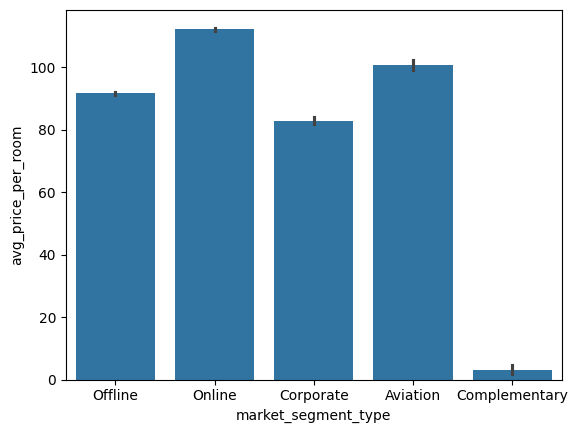

In [23]:
sns.barplot(x="market_segment_type",y="avg_price_per_room",data=data)

# Observation

Online market segments contributed the highest number of hotel bookings.

This suggests that customers prefer online booking platforms over offline methods.

**What percentage of bookings are canceled?**

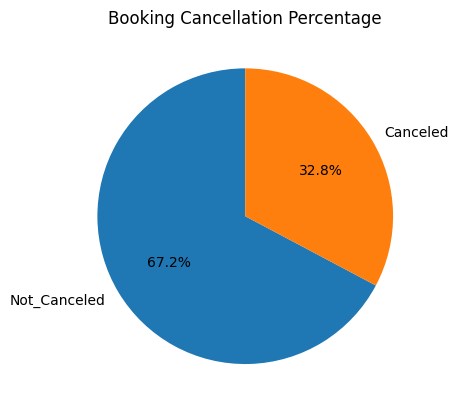

In [24]:
import matplotlib.pyplot as plt

# Count values
counts = data['booking_status'].value_counts()

# Pie chart
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Booking Cancellation Percentage")
plt.show()

**Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

<Axes: xlabel='booking_status', ylabel='repeated_guest'>

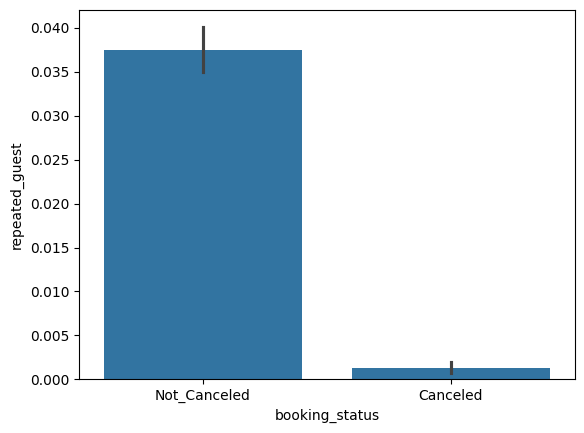

In [25]:
sns.barplot(x="booking_status",y="repeated_guest",data=data)

This shows that repeated guests are not   likely to cancel.




**Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

<Axes: xlabel='booking_status', ylabel='no_of_special_requests'>

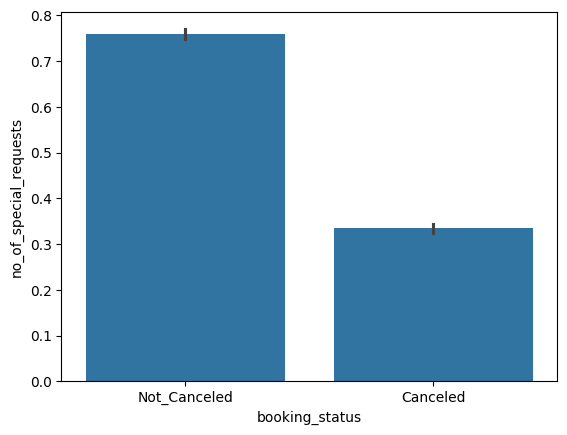

In [26]:
sns.barplot(x="booking_status",y="no_of_special_requests",data=data)

# Univariate Analysis

Univariate analysis focuses on understanding individual features separately using:
- Countplots
- Histograms
- Boxplots

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'total_stay'],
      dtype='object')
   no_of_weekend_nights  no_of_week_nights  total_stay
0                     1                  2           3
1                     2                  3           5
2                     2                  1           3
3                     0                  2           2
4                     1                  1           2


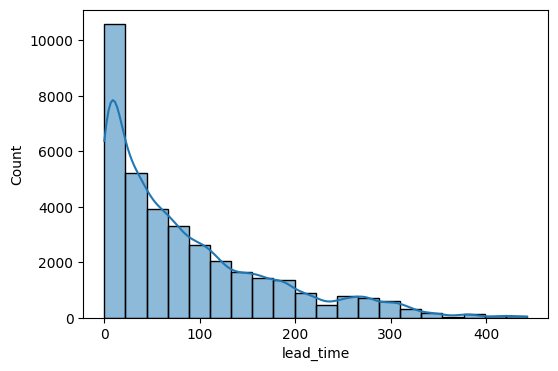

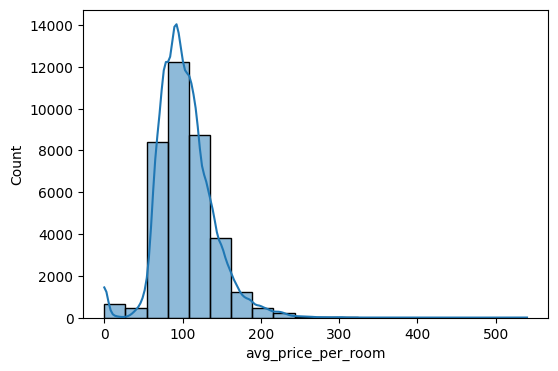

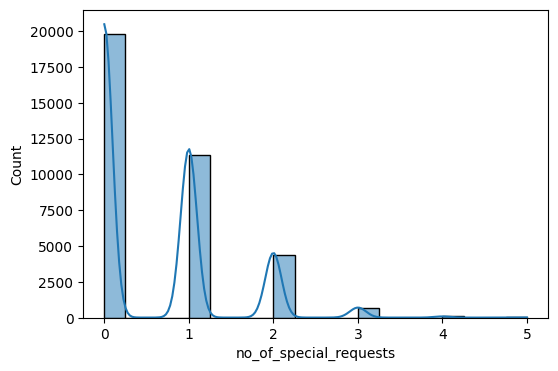

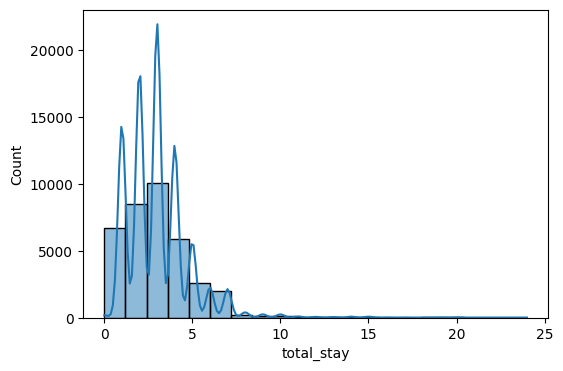

In [49]:
# Check all column names
print(data.columns)

# Create total_stay column
data['total_stay'] = (
    data['no_of_weekend_nights'] +
    data['no_of_week_nights']
)

# Verify column created successfully
print(data[['no_of_weekend_nights',
          'no_of_week_nights',
          'total_stay']].head())

for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,bins=20)

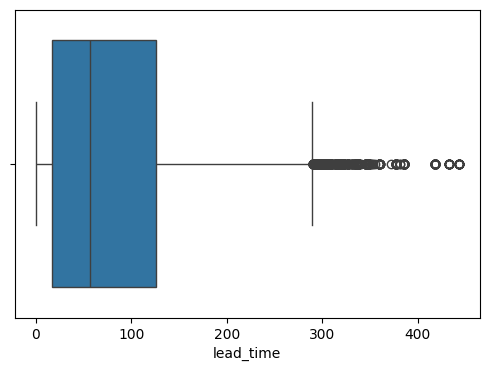

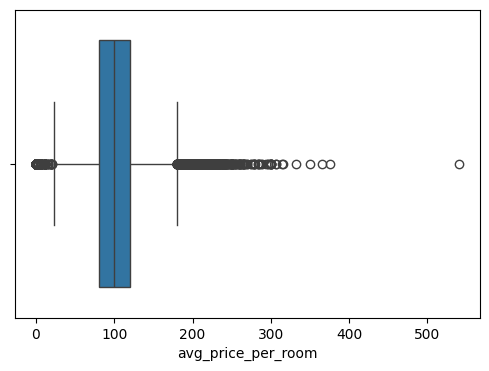

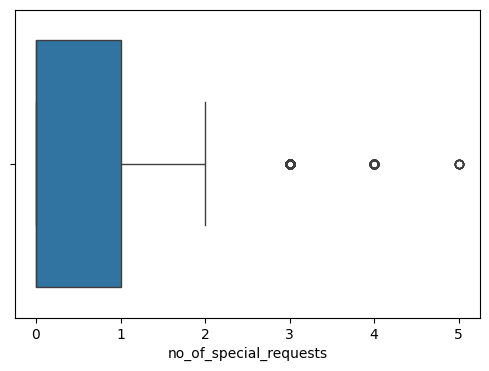

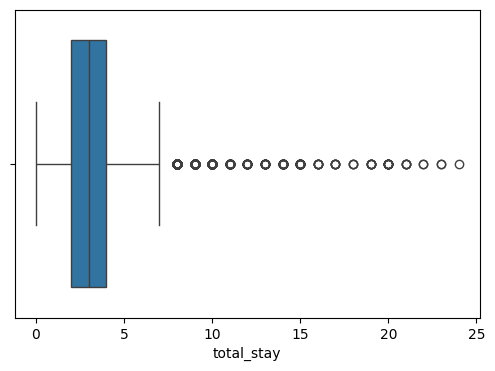

In [50]:
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])

## Bivariate Analysis
Bivariate analysis helps understand relationships between two variables and their impact on booking cancellations.

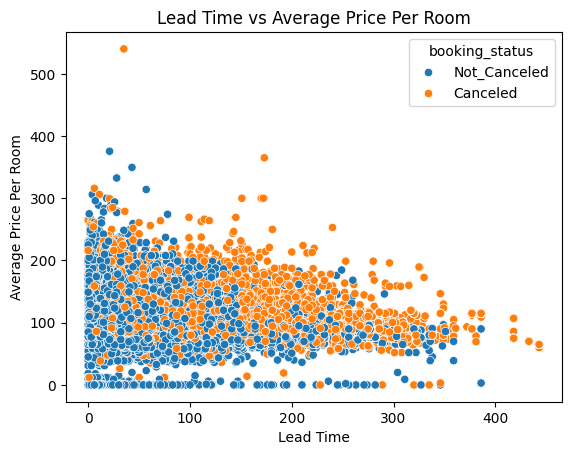

In [29]:
sns.scatterplot(x='lead_time',y='avg_price_per_room',data=data,hue='booking_status')
plt.title('Lead Time vs Average Price Per Room')
plt.xlabel('Lead Time')
plt.ylabel('Average Price Per Room')
plt.show()

#Observation
The scatter plot visualizes the relationship between lead time and average room price, colored by booking status (canceled or not canceled).


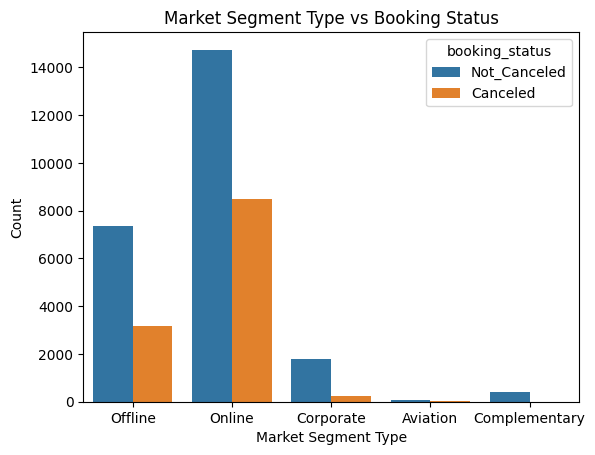

In [31]:
sns.countplot(x="market_segment_type",hue="booking_status",data=data)
plt.title("Market Segment Type vs Booking Status")
plt.xlabel("Market Segment Type")
plt.ylabel("Count")
plt.show()

#Observation
The grouped bar chart indicates that the 'Online TA' segment has a higher proportion of canceled bookings compared to other segments. This suggests that customers acquired through online travel agencies might be more prone to cancellations. The hotel could consider implementing stricter cancellation policies or offering incentives for non-refundable bookings for this segment.


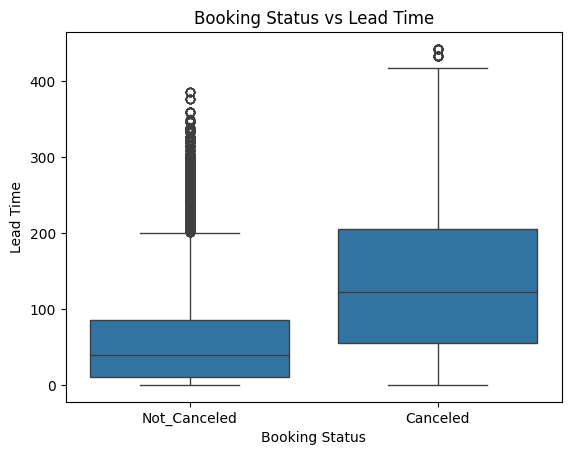

In [33]:
sns.boxplot(x="booking_status",y="lead_time",data=data)
plt.title("Booking Status vs Lead Time")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time")
plt.show()

#Observation
The box plot reveals that canceled bookings generally have longer lead times compared to bookings that are not canceled. This suggests that guests who book further in advance are more prone to cancellations. The hotel could consider implementing policies or incentives to encourage shorter lead times or early confirmations for reservations made well in advance.


# Correlation Analysis

Correlation analysis is used to identify relationships between numerical features.

Highly correlated features may influence model performance.

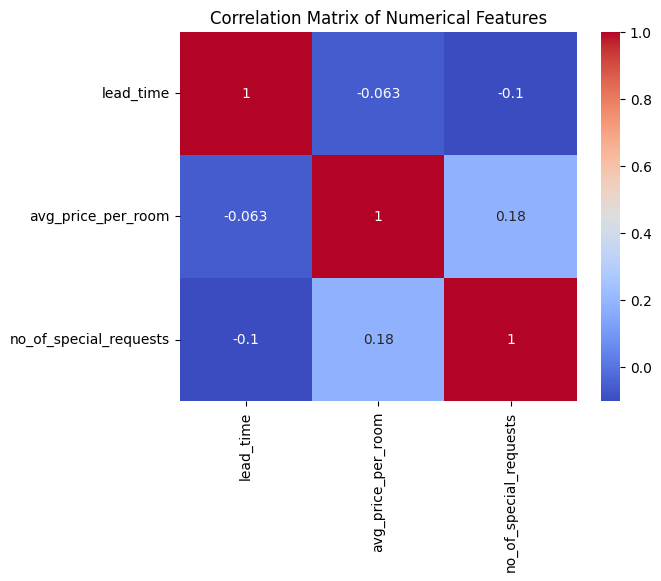

In [38]:
selected_feature =['lead_time','avg_price_per_room','no_of_special_requests']
correlation_matrix = data[selected_feature].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#Observations:
* Lead Time and Average Price: You might observe a weak positive correlation, suggesting that bookings made further in advance tend to have slightly higher prices, but the relationship is not very strong.
* Lead Time and Special Requests: There might be a weak positive correlation, indicating that guests who book further in advance are slightly more likely to have special requests.
* Average Price and Special Requests: There might be a weak to moderate positive correlation, suggesting that guests who pay higher prices for rooms tend to make more special requests.

## Data Preprocessing
Before training the machine learning model:
- Numerical features are scaled
- Categorical features are encoded

This ensures the data is in a suitable format for model training.

In [ ]:
# Data Scaling - Scaling numerical feature to a common range to prevent features with larger values  from dominating the model.
numeric_column =['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'total_stay']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])


# Observation

Feature scaling standardized the numerical variables and reduced differences in feature ranges.

This helps Logistic Regression perform more efficiently and improves model stability.

##Feature Enginnering

New meaningful features are created from existing columns to improve model performance.

A new feature:
- `total_stay`

is created using:
- Weekend nights
- Week nights

In [53]:
#One HOt Encoding
categorical_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
                        'required_car_parking_space', 'repeated_guest']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_column),

        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ])
X = data.drop(['booking_status', 'Booking_ID'], axis=1)
y = data['booking_status']

# Observation

One-Hot Encoding successfully transformed categorical variables into numerical format, allowing the Logistic Regression model to process text-based features efficiently.

##Train Test Split The Data

The dataset is divided into:
- Training Data
- Testing Data

Training data is used to train the model, while testing data is used to evaluate model performance.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [55]:
# Fit and Transform the Data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

##Model Building
# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

The model predicts whether a hotel booking will:
- Be Canceled
- Not Be Canceled

In [63]:
data['total_stay'] = (
    data['no_of_weekend_nights'] +
    data['no_of_week_nights']
)

X = data.drop(['booking_status', 'Booking_ID'], axis=1)
y = data['booking_status']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),

        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score:
0.8066161268090972

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.75      0.63      0.68      2416
Not_Canceled       0.83      0.89      0.86      4839

    accuracy                           0.81      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.81      0.80      7255


Confusion Matrix:
[[1523  893]
 [ 510 4329]]


# Confusion Matrix

The confusion matrix helps visualize:
- Correct predictions
- Incorrect predictions
- False positives
- False negatives

# Conclusion

In this project, hotel booking data was analyzed to understand booking behavior and cancellation patterns.

Important insights discovered:
- Online bookings were more common among customers.
- Repeated guests were less likely to cancel bookings.
- Customers with special requests showed lower cancellation rates.
- Booking patterns varied across room types and market segments.

A Logistic Regression model was built after preprocessing and feature engineering.

The model successfully predicted booking cancellations with good performance and demonstrated how machine learning can assist hotels in:
- Reducing cancellation losses
- Improving booking management
- Enhancing customer experience
- Making data-driven business decisions

This project highlights the practical application of data science and machine learning in the hospitality industry.